# 3.1 Whole-brain CM-FC decoupling in MCI

In [5]:
from ana_utils import *
import warnings
warnings.filterwarnings("ignore")

In [6]:
output_dir = f"{PROJ_HOME}/results/1_global_CFC"
os.makedirs(output_dir, exist_ok=True)
print("Output dir:", output_dir)

# Convert colors in PAL4 and CM_ARR_COLOR to hex format
colors_hex = [mcolors.to_hex(color) for color in PAL4]
cm_arr_hex = [mcolors.to_hex(color) for color in CM_ARR_COLOR]

# Print the assigned variables for verification
print("Colors (hex):", colors_hex)
print("CM Array Colors (hex):", cm_arr_hex)
print("Language Model Labels:", )

Output dir: D:\Shanghaitec\PROJECT\CSVD_neo/results/1_global_CFC
Colors (hex): ['#fa7f6f', '#ffbe7a', '#82b0d2']
CM Array Colors (hex): ['#9a7bb7', '#9a7bb7', '#7b8cb7', '#7b8cb7', '#999999']
Language Model Labels:


In [7]:
# Merge CFC data for five LMs
merged_df = pd.concat(
    [
        pd.read_csv(f"{output_dir}/_lr-global_cfc-{tract_lab}.csv").assign(Tractography=tract_lab)
        for tract_lab in TRACT_LABS
    ],
    ignore_index=True,
)

# Calculate merged_diff_df (INT - WMH for each pid and Group)
int_sub_df = merged_df[merged_df.Tractography == TRACT_LABS[1]].set_index(["pid", "Group"])
wmh_sub_df = merged_df[merged_df.Tractography == TRACT_LABS[2]].set_index(["pid", "Group"])

merged_diff_df = (int_sub_df[CM_LABS] - wmh_sub_df[CM_LABS]).reset_index()

## Table S3. Comparison of the global CM-FC coupling R2(All)

In [ ]:
comp_res = pd.DataFrame(
    []
)
post_hoc_res = pd.DataFrame(
    []
)
anova_df = merged_df
res = pg_anova(anova_df[anova_df.Tractography==TRACT_LABS[0]], col_name="rsq", factor="Group")
anova_res = res[0].assign(
    Tractography=TRACT_LABS[0],
)
post_hoc_res = pd.concat(
    [post_hoc_res, res[1]],
    ignore_index=True
    )
        
comp_res = pd.concat(
    [comp_res, anova_res],
    ignore_index=True
)
    
comp_res["P_corrected"] = add_statistic_annotation(fdr_correction(comp_res["p-unc"].to_list()))
post_hoc_res["P"] = add_statistic_annotation(post_hoc_res["pval"].to_list())
comp_res.round(3).to_csv(f"{output_dir}/global_CFC_comparison-R2-All.csv")
post_hoc_res.round(3).to_csv(f"{output_dir}/global_CFC_comparison-R2-All-posthoc.csv")

## Table S3. Comparison of the global CM-FC coupling R2 (INT and WMH)

In [ ]:
# Two-way ANOVA between int_subtbl and wmh_subtbl
int_wmh_df = pd.concat(
    [
        int_sub_df.reset_index().assign(Tractography="int"),
        wmh_sub_df.reset_index().assign(Tractography="wmh"),
    ],
    ignore_index=True,
)

In [ ]:
anova_res_df = pd.DataFrame(
    []
)
posthoc_res_df = pd.DataFrame(
    []
)
anova_df = int_wmh_df
anova_res, posthoc = pg_mix_anova(anova_df)

anova_res_df = pd.concat(
    [anova_res_df, anova_res],
    ignore_index=True
)
posthoc_res_df = pd.concat(
    [posthoc_res_df, posthoc],
    ignore_index=True
)
    
anova_res_df["P"] = add_statistic_annotation(anova_res_df["p-unc"].to_list())
anova_res_df["P_corrected"] = anova_res_df.groupby("Source")["p-unc"].transform(
    lambda p: add_statistic_annotation(fdr_correction(p.tolist()))
)
posthoc_res_df["P"] = add_statistic_annotation(posthoc_res_df["pval"].to_list())
anova_res_df.round(3).to_csv(f"{output_dir}/global_CFC_comparison-R2-INT_WMH.csv")
posthoc_res_df.round(3).to_csv(f"{output_dir}/global_CFC_comparison-R2-INT_WMH-posthoc.csv")
print("Mixed ANOVA Result:")

Mixed ANOVA Result:


## Table S4. Comparison of the dominance for global CM-FC coupling (All)

In [ ]:
posthoc_res_df = pd.DataFrame([])
anova_res_df = pd.DataFrame([])
for cm_lab in CM_LABS:
    anova_df = merged_df.copy()
    res = pg_anova(anova_df[anova_df["Tractography"]==TRACT_LABS[0]], col_name=cm_lab, factor="Group")
    anova_res = res[0].assign(
        Tractography="All",
        CM=cm_lab[:2].upper(),
    )
    posthoc_res_df = pd.concat(
        [posthoc_res_df, res[1].assign(
            CM=cm_lab[:2].upper()
        )],
        ignore_index=True
        )
        
    anova_res_df = pd.concat(
        [anova_res_df, anova_res],
        ignore_index=True
    )
    
anova_res_df["P"] = add_statistic_annotation(anova_res_df["p-unc"].to_list())
posthoc_res_df["P"] = add_statistic_annotation(posthoc_res_df["pval"].to_list())
anova_res_df.round(3).to_csv(f"{output_dir}/global_CFC_comparison-Dominance-All.csv")
posthoc_res_df.round(3).to_csv(f"{output_dir}/global_CFC_comparison-Dominance-All-posthoc.csv")

## Table S4. Comparison of the dominance for global CM-FC coupling (INT-WMH)

In [ ]:
posthoc_res_df = pd.DataFrame([])
anova_res_df = pd.DataFrame([])
for cm_lab in CM_LABS:

        anova_df = int_wmh_df.copy()
        anova_res, posthoc_res = pg_mix_anova(anova_df, col_name=cm_lab)
        # ANOVA result
        anova_res_df = pd.concat(
            [
                anova_res_df,
                anova_res.assign(
                    CM=cm_lab[:2].upper(),
                ),
            ],
            ignore_index=True,
        )
        # Post-hoc result
        posthoc_res_df = pd.concat(
            [
                posthoc_res_df,
                posthoc_res.assign(
                    CM=cm_lab[:2].upper(),
                ),
            ],
            ignore_index=True,
        )

anova_res_df["P"] = add_statistic_annotation(anova_res_df["p-unc"].to_list())
posthoc_res_df["P"] = add_statistic_annotation(posthoc_res_df["pval"].to_list())
anova_res_df.round(3).to_csv(f"{output_dir}/global_CFC_comparison-Dominance-INT_WMH.csv")
posthoc_res_df.round(3).to_csv(
    f"{output_dir}/global_CFC_comparison-Dominance-INT_WMH-posthoc.csv"
)


In [ ]:

# T test of tractography
# Initialize an empty DataFrame to store all results
all_ttest_res = pd.DataFrame()

for cm_lab in CM_LABS:
    # Perform the paired t-test with Tractography between 'int' and 'wmh' and use pid as the paired index using pingouuin
    int_wmh_df = merged_df[merged_df.Tractography.isin(TRACT_LABS[1:3])][["pid", "Tractography", cm_lab]]
    ttest_res = pg.pairwise_ttests(data=int_wmh_df, dv=cm_lab, within="Tractography", subject="pid", padjust="fdr_bh")
    
    # Add mean and std columns
    mean_std_df = int_wmh_df.groupby("Tractography")[cm_lab].agg(["mean", "std"]).reset_index()
    ttest_res = ttest_res.merge(mean_std_df, left_on="A", right_on="Tractography").rename(columns={"mean": "mean_A", "std": "std_A"}).drop(columns=["Tractography"])
    ttest_res = ttest_res.merge(mean_std_df, left_on="B", right_on="Tractography").rename(columns={"mean": "mean_B", "std": "std_B"}).drop(columns=["Tractography"])
    
    # Add mean difference column
    ttest_res["mean_diff"] = ttest_res["mean_A"] - ttest_res["mean_B"]
    
    # Add the current `cm_lab` as a column for identification
    ttest_res["CM"] = cm_lab
    
    # Append the results to the combined DataFrame
    all_ttest_res = pd.concat([all_ttest_res, ttest_res], ignore_index=True)

# Save the combined results to a single CSV file
all_ttest_res.round(3).to_csv(f"{output_dir}/global_CFC_comparison-Dominance-INT_WMH-paired_ttest.csv", index=False)


## Figuer 2. Swarmplot for global R2

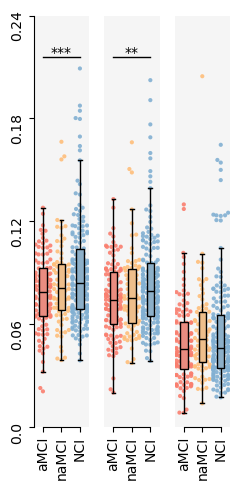

In [ ]:
# Set the y-axis limit and create subplots
ylim = 0.24
fig, axes = plt.subplots(nrows=1, ncols=len(TRACT_LABS), figsize=(2.5, 5))
axes = axes.flatten()
comp_res = []

# Iterate through each language model label
for i, tract_lab in enumerate(TRACT_LABS):
    ax = axes[i]
    lr_res_tbl = merged_df[merged_df.Tractography == tract_lab]
    
    anova_res = pg_anova(lr_res_tbl)
    posthoc_p = anova_res[4]
    p_group = anova_res[3]
    
    # Plot swarmplot
    plot_ax_swarmplot(lr_res_tbl, ax, i, x="Group", y="rsq", ylim=0.24, swarmsize=3)
    ax.set_ylabel("")
    ax.set_yticks(np.round(np.linspace(0, ylim, 5), 2))
    ax.set_yticklabels(ax.get_yticks(), rotation=90)

    # Adjust axis appearance
    if i > 0:
        ax.spines["left"].set_color("None")
        ax.set(yticks=[], ylabel="")
    if ax.get_ylim()[0] > ax.get_ylim()[1]:
        ax.invert_yaxis()
    sns.despine(trim=True, ax=ax)

    # Add significance lines and annotations
    sig_line_xs = [ (1 / 6, 5 / 6), (1 / 6, 1 / 2),(1 / 2, 5 / 6)]
    for j, posthoc_p_val in enumerate(posthoc_p):
        if p_group < 0.05 and posthoc_p_val < 0.05:
            ax.text(
                1+ 0.5 * j,
                ylim * (0.9 - j * 0.1),
                get_stats_sig(posthoc_p_val),
                ha="center",
            )
            ax.axhline(
                ylim * (0.9 - j * 0.1),
                xmin=sig_line_xs[j][0],
                xmax=sig_line_xs[j][1],
                color="black",
                linestyle="-",
                lw=1,
                zorder=1,
            )


# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(f"{output_dir}/global_CFC_swarmplot-R2.svg", bbox_inches="tight", dpi=300)


## Figuer 2. Radarplot

In [ ]:

# Plot radar charts
def plot_radar(ax, values, angles, color, label, linestyle="solid"):
    ax.plot(angles, values, linewidth=1, linestyle=linestyle, color=color, label=label)
    ax.set_facecolor("white")

def get_angles(N):
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    return angles + angles[:1]

def get_rsq_mean(tbl, groupby="Group", index="pid"):
    return tbl.set_index(index).groupby(groupby).mean()

def plot_radar_for_tbl(tbl, title, ylim, colors, labels, angles, ax, linestyle="solid"):
    for idx, label in enumerate(labels):
        values = tbl.loc[label].values
        values = np.concatenate((values, [values[0]]))
        plot_radar(ax, values, angles, colors[idx], label, linestyle)
    ax.set_title(title)
    ax.set_yticks(np.round(np.linspace(0, ylim, 4), 3))
    plt.xticks(angles[:-1], CM_ARR_SHORT)
    locs, xticklabels = plt.xticks()
    [plt.setp(xticklabels[i], color=cm_arr_hex[i]) for i in range(len(xticklabels))]


In [ ]:
# All fibers
ylim = 0.025
fig, axes = plt.subplots(1, 2, figsize=(8, 3), subplot_kw={"polar": True})

# Plot 1: All
lr_res_tbl = merged_df[merged_df.Tractography == TRACT_LABS[0]][["Group", "pid", *[item[0] for item in CM_ARR[1:]]]]
lr_rsq_mean = get_rsq_mean(lr_res_tbl)
categories = list(lr_rsq_mean.columns)
N = len(categories)
angles = get_angles(N)
plot_radar_for_tbl(lr_rsq_mean, "All", ylim, colors_hex, DISGROUPS, angles, axes[0])

# Plot 2: INT & WMH
for tract_lab, linestyle in zip(TRACT_LABS[1:3], ["solid", ":"]):
    lr_res_tbl = merged_df[merged_df.Tractography == tract_lab][["Group", *[item[0] for item in CM_ARR[1:]]]]
    lr_rsq_mean = lr_res_tbl.groupby("Group").mean()
    plot_radar_for_tbl(lr_rsq_mean, "", ylim, colors_hex, DISGROUPS, get_angles(len(lr_rsq_mean.columns)), axes[1], linestyle)
axes[1].set_title("INT & WMH")

plt.tight_layout()
plt.savefig(f"{output_dir}/global_CFC_radarplot-Dominance-All.svg", bbox_inches="tight")


## Figuer 2. Heatmap

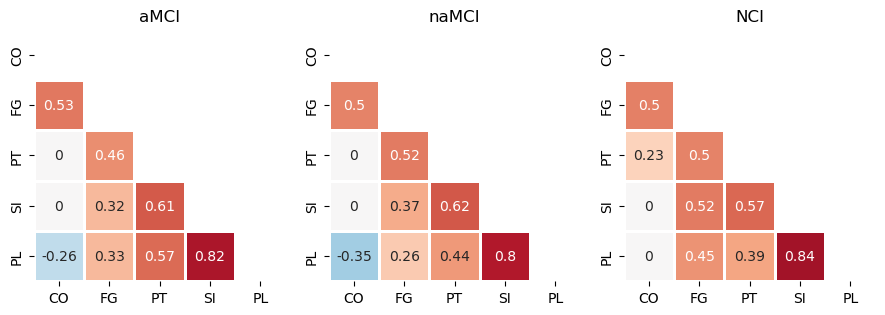

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))  # Create a 1x3 subplot layout
axes = axes.flatten()

# Initialize a list to store Pearson correlation results
all_pearson_stats = []

for i, dg in enumerate(DISGROUPS):
    dg_merged_df = merged_df[(merged_df.Group == dg) & (merged_df.Tractography == TRACT_LABS[0])]
    pearson_stat, pearson_mat = [], np.zeros((len(CM_LABS), len(CM_LABS)))
    for j, cm1 in enumerate(CM_LABS):
        for k, cm2 in enumerate(CM_LABS):
            r, p = sp.stats.pearsonr(dg_merged_df[cm1], dg_merged_df[cm2])
            pearson_stat.append({"Group": dg, "cat": "All", "int": cm1, "wmh": cm2, "r": r, "p": p})
            if p < 0.05:
                pearson_mat[j, k] = r

    # Append the results for this group
    all_pearson_stats.extend(pearson_stat)

    sns.heatmap(
        pearson_mat,
        cmap="RdBu_r",
        vmax=1,
        vmin=-1,
        linewidths=1,
        square=True,
        annot=True,
        mask=np.triu(np.ones_like(pearson_mat, dtype=bool)),
        xticklabels=[cm[:2].upper() for cm in CM_LABS],
        yticklabels=[cm[:2].upper() for cm in CM_LABS],
        ax=axes[i],
        cbar=False,
    )
    axes[i].set_title(dg)

plt.tight_layout()
plt.savefig(f"{output_dir}/corr_heat_subplots.svg", bbox_inches="tight")

# Save the Pearson correlation results to a CSV file
pearson_df = pd.DataFrame(all_pearson_stats).round(3)
pearson_df.to_csv(f"{output_dir}/global_CFC_Corr-Dominance-All.csv", index=False)


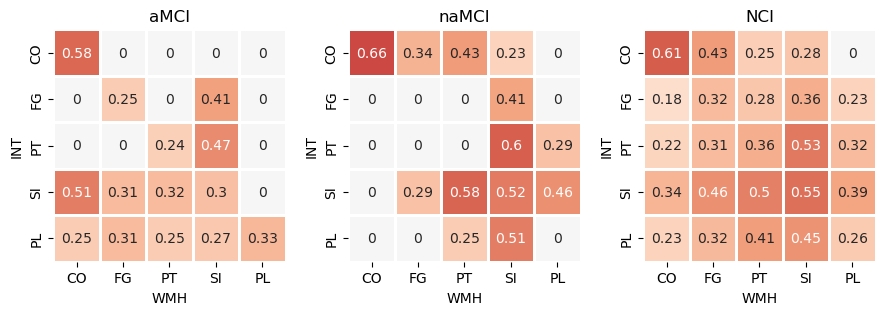

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))  # Create a 1x3 subplot layout
axes = axes.flatten()

for i, dg in enumerate(DISGROUPS):
    dg_int_wmh_df = int_wmh_df[int_wmh_df.Group == dg]
    # Pivot INT/WMH values by pid and Group
    int_wmh_tbl = dg_int_wmh_df.set_index("pid").pivot_table(index=["pid", "Group"], values=CM_LABS, columns="Tractography")

    pearson_stat, pearson_mat = [], np.zeros((len(CM_LABS), len(CM_LABS)))
    for j, cm1 in enumerate(CM_LABS):
        for k, cm2 in enumerate(CM_LABS):
            r, p = sp.stats.pearsonr(int_wmh_tbl[cm1]["int"], int_wmh_tbl[cm2]["wmh"])
            pearson_stat.append({"cat": "int-wmh", "int": cm1, "wmh": cm2, "r": r, "p": p})
            # Plot (sns.regplot) and save figure
            # plt.figure(figsize=(4, 4))
            # sns.regplot(
            #     x=int_wmh_tbl[cm1]["int"],
            #     y=int_wmh_tbl[cm2]["wmh"],
            #     scatter_kws={"s": 20, "alpha": 0.7},
            #     line_kws={"color": "red"},
            # )
            # plt.xlabel(f"INT - {cm1[:2].upper()}")
            # plt.ylabel(f"WMH - {cm2[:2].upper()}")
            # plt.savefig(f"{output_dir}/regplot_{dg}_INT-{cm1[:2].upper()}_WMH-{cm2[:2].upper()}.svg", bbox_inches="tight")
            
            if p < 0.05:
                pearson_mat[j, k] = r

    # Draw the heatmap of the correlation coefficients
    sns.heatmap(
        pearson_mat,
        cmap="RdBu_r",
        vmax=1,
        vmin=-1,
        linewidths=1,
        square=True,
        annot=True,
        ax=axes[i],
        cbar=False,
        
        xticklabels=[cm[:2].upper() for cm in CM_LABS],
        yticklabels=[cm[:2].upper() for cm in CM_LABS],
    )
    axes[i].set_title(dg)
    axes[i].set_xlabel("WMH")
    axes[i].set_ylabel("INT")

plt.tight_layout()
plt.savefig(f"{output_dir}/corr_heat_int_wmh.svg", bbox_inches="tight")
